# Pregunta 3: Reescalado e Interpolación Bilineal (20 puntos)

Implemente una función para reescalar una imagen de dimensiones arbitrarias mediante un factor real $s$ en el intervalo $0.5 \le s \le 2$. La función deberá operar tanto en reducción como en ampliación, calcular automáticamente el tamaño de la salida y funcionar con imágenes en escala de grises y RGB.

El reescalado deberá realizarse mapeando cada coordenada de la imagen de salida hacia una posición de la imagen original (*backward mapping*). Defina explícitamente la convención utilizada para relacionar ambos sistemas de coordenadas.

---

## P3 — Implementación (6 puntos)
- [ ] Implemente dos modos de interpolación: **vecino más cercano** e **interpolación bilineal**.
- [ ] Cálculo explícito de los 4 vecinos, pesos para posiciones no enteras y tratamiento de bordes.
- [ ] Prohibido el uso de funciones externas de reescalado o interpolación.
- [ ] Tratamiento explícito del redondeo de dimensiones cuando $s \times \text{dim}$ no es entero.

---

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import cv2

from codigo.p3_reescalado import reescalar_imagen
from codigo.utilidades import cargar_imagen_rgb

os.makedirs('../figuras/p3', exist_ok=True)
print("Entorno listo para Pregunta 3.")

Entorno listo para Pregunta 3.


## P3 — Experimentación y Análisis (8 puntos)
1. **Factores no enteros:** Utilice al menos 4 factores de escala no enteros ($0.5 \le s \le 2$), al menos dos con $s < 1$ y dos con $s > 1$ (no usar $s=1$ ni factores enteros en comparaciones principales).
2. **Comparación NN vs. Bilineal:** Compare sistemáticamente ambos métodos con las mismas imágenes, factores y recortes ampliados.
3. **Diversidad de imágenes:** Utilice al menos 2 imágenes diferentes, incluyendo una con bordes fuertes, líneas finas o detalles pequeños.
4. **Reducción vs. Ampliación:** Analice por separado artefactos, detalle, suavidad y estructura en ambos regímenes.
5. **Reducción seguida de ampliación:** Realice una reducción seguida de una ampliación que recupere aproximadamente el tamaño original; compare con la original y analice la pérdida de información.
6. **Reescalados sucesivos vs. único:** Compare varios reescalados sucesivos frente a un único reescalado con factor equivalente al producto.
7. **Aliasing en reducción:** Identifique al menos un caso de aliasing o pérdida de estructuras finas en reducción y analice su causa.
8. **Exploración adicional libre:** Realice al menos una exploración adicional justificada.

---

In [2]:
img_crop = cargar_imagen_rgb("P3_IMG_2387_crop.tif")
img_scenery = cargar_imagen_rgb("P1_IMG_2402.tif")

print(f"P3_IMG_2387_crop dimensiones: {img_crop.shape}")
print(f"P1_IMG_2402 dimensiones:      {img_scenery.shape}")

P3_IMG_2387_crop dimensiones: (1908, 1827, 3)
P1_IMG_2402 dimensiones:      (5202, 3464, 3)


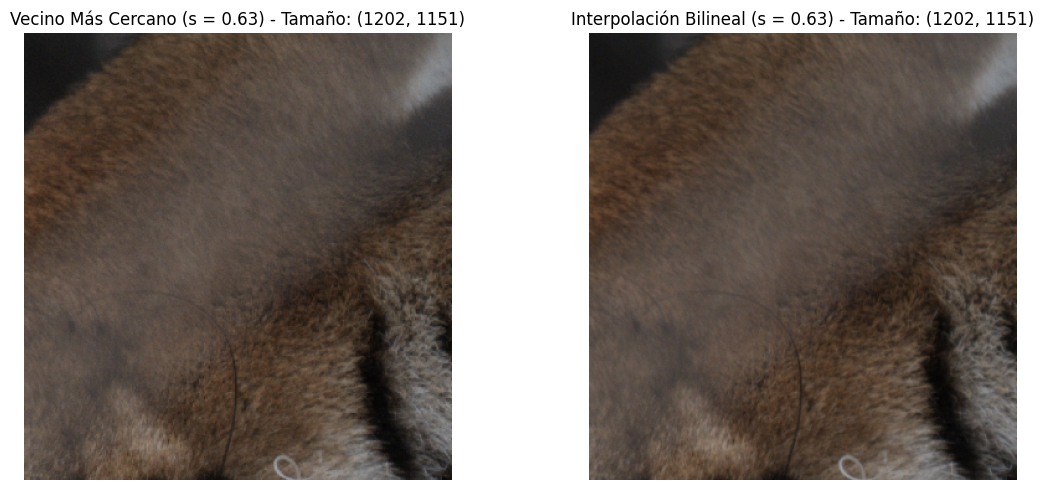

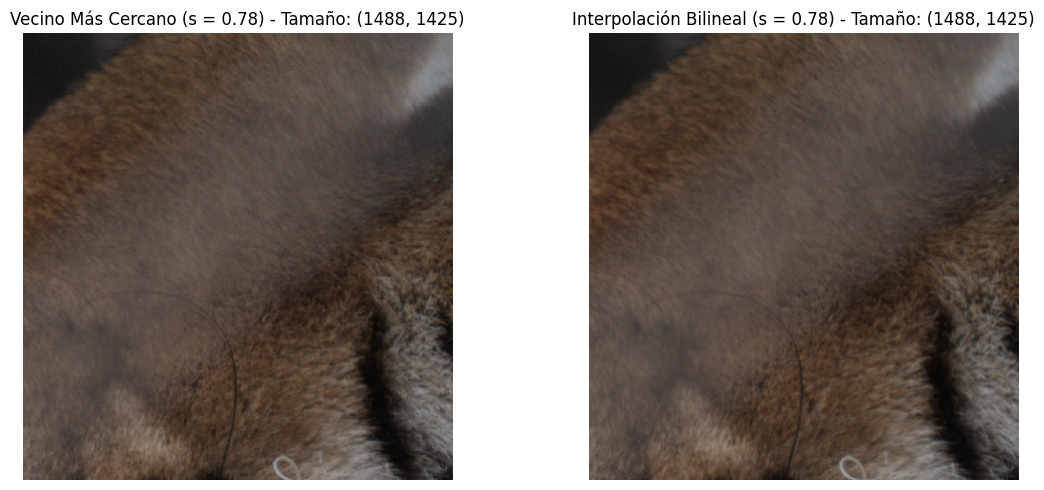

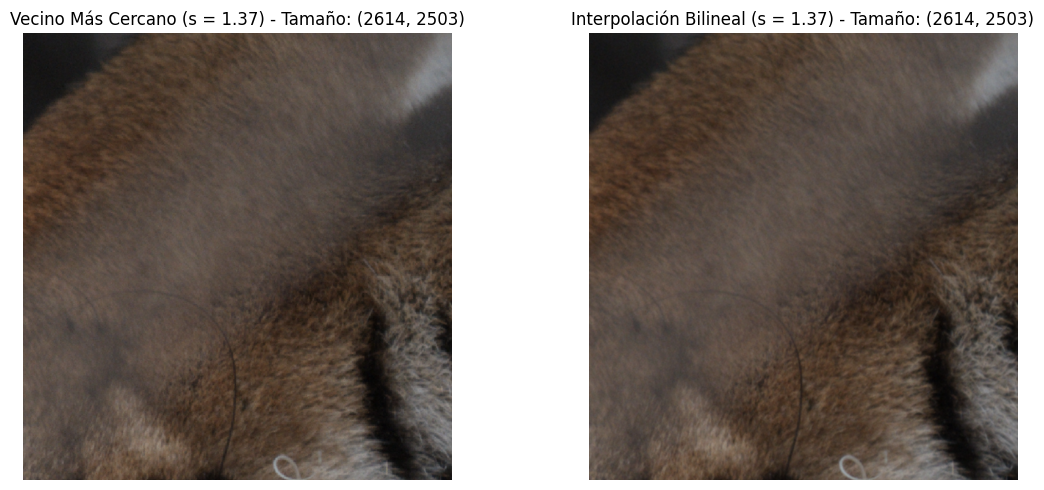

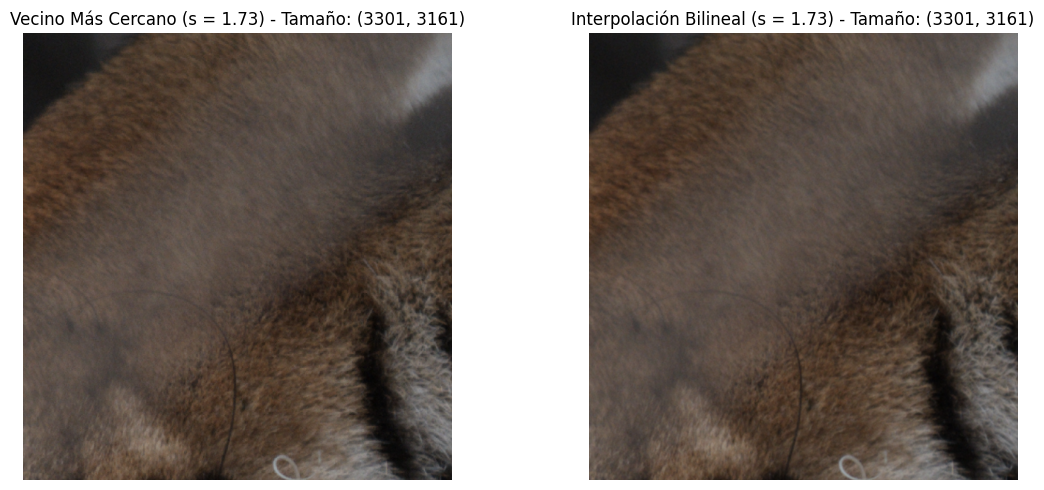

In [3]:
factores_no_enteros = [0.63, 0.78, 1.37, 1.73]

for s in factores_no_enteros:
    res_nn = reescalar_imagen(img_crop, s=s, metodo="vecino")
    res_bi = reescalar_imagen(img_crop, s=s, metodo="bilineal")
    
    # Recorte representativo para apreciar diferencias de interpolación
    cy = slice(int(res_nn.shape[0] * 0.3), int(res_nn.shape[0] * 0.6))
    cx = slice(int(res_nn.shape[1] * 0.3), int(res_nn.shape[1] * 0.6))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(res_nn[cy, cx])
    axes[0].set_title(f"Vecino Más Cercano (s = {s}) - Tamaño: {res_nn.shape[:2]}")
    axes[0].axis('off')

    axes[1].imshow(res_bi[cy, cx])
    axes[1].set_title(f"Interpolación Bilineal (s = {s}) - Tamaño: {res_bi.shape[:2]}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.savefig(f"../figuras/p3/01_comparacion_s_{str(s).replace('.', '_')}.png", dpi=300, bbox_inches='tight')
    plt.show()

Dimensiones de comparación: (1907, 1827)
Error Absoluto Medio (MAE) - Vecino:   0.00998
Error Absoluto Medio (MAE) - Bilineal: 0.00699


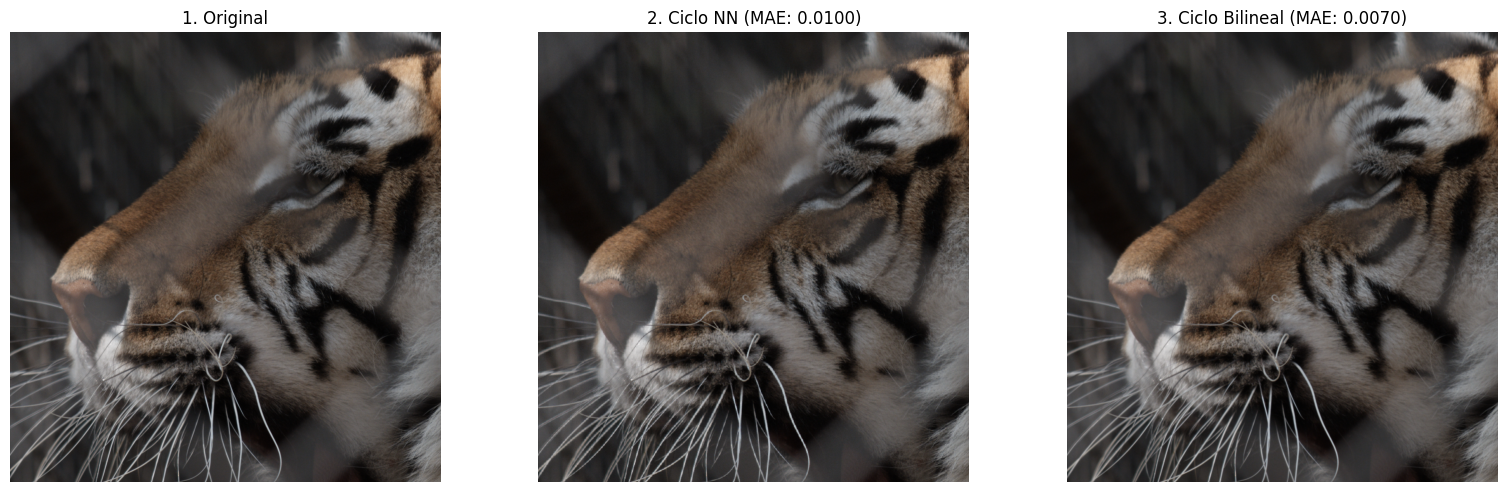

In [6]:
s_red = 0.55
s_rec = 1.0 / s_red  # Factor inverso aproximado

# Ciclo con Vecino más cercano
down_nn = reescalar_imagen(img_crop, s=s_red, metodo="vecino")
rec_nn = reescalar_imagen(down_nn, s=s_rec, metodo="vecino")

# Ciclo con Bilineal
down_bi = reescalar_imagen(img_crop, s=s_red, metodo="bilineal")
rec_bi = reescalar_imagen(down_bi, s=s_rec, metodo="bilineal")

# Determinar dimensiones comunes mínimas para comparar sin error de broadcasting
H_comun = min(img_crop.shape[0], rec_nn.shape[0], rec_bi.shape[0])
W_comun = min(img_crop.shape[1], rec_nn.shape[1], rec_bi.shape[1])

orig_eval = img_crop[:H_comun, :W_comun]
rec_nn_eval = rec_nn[:H_comun, :W_comun]
rec_bi_eval = rec_bi[:H_comun, :W_comun]

error_nn = np.mean(np.abs(orig_eval - rec_nn_eval))
error_bi = np.mean(np.abs(orig_eval - rec_bi_eval))

print(f"Dimensiones de comparación: ({H_comun}, {W_comun})")
print(f"Error Absoluto Medio (MAE) - Vecino:   {error_nn:.5f}")
print(f"Error Absoluto Medio (MAE) - Bilineal: {error_bi:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(orig_eval)
axes[0].set_title("1. Original")
axes[0].axis('off')

axes[1].imshow(rec_nn_eval)
axes[1].set_title(f"2. Ciclo NN (MAE: {error_nn:.4f})")
axes[1].axis('off')

axes[2].imshow(rec_bi_eval)
axes[2].set_title(f"3. Ciclo Bilineal (MAE: {error_bi:.4f})")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("../figuras/p3/02_ciclo_reduccion_recuperacion.png", dpi=300, bbox_inches='tight')
plt.show()

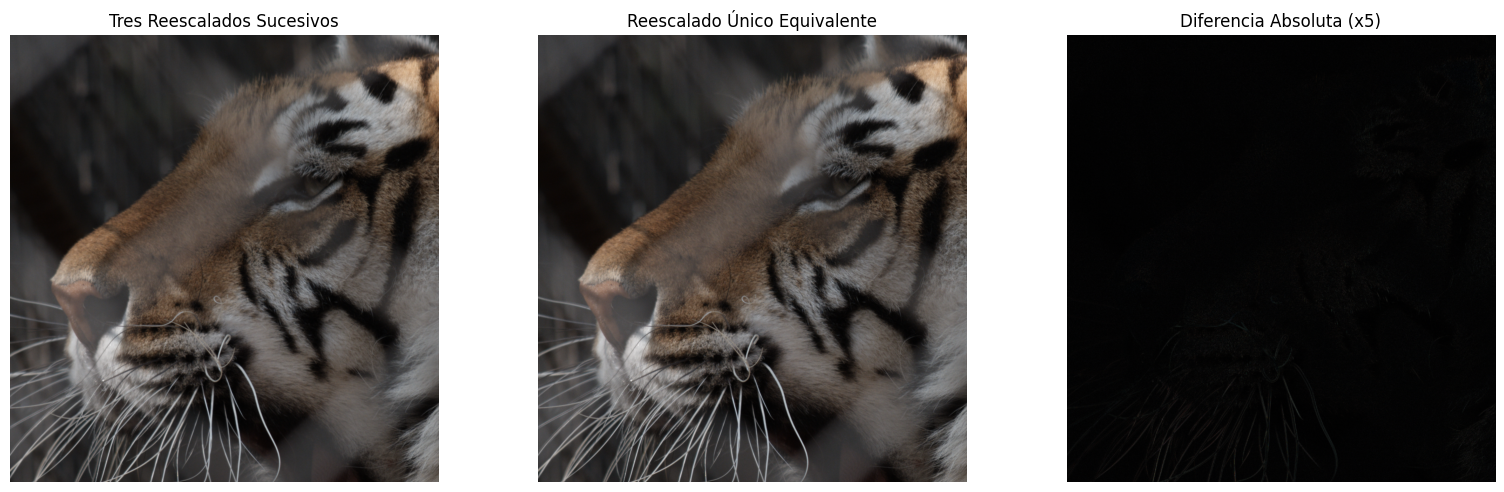

In [7]:
# Factores sucesivos: s1 * s2 * s3 = 0.8 * 1.4 * 1.25 = 1.40
s1, s2, s3 = 0.8, 1.4, 1.25
s_equiv = s1 * s2 * s3

# Tres reescalados en cadena
img_step1 = reescalar_imagen(img_crop, s=s1, metodo="bilineal")
img_step2 = reescalar_imagen(img_step1, s=s2, metodo="bilineal")
img_sucesivo = reescalar_imagen(img_step2, s=s3, metodo="bilineal")

# Un único reescalado equivalente
img_directo = reescalar_imagen(img_crop, s=s_equiv, metodo="bilineal")

# Ajuste fino por redondeo
min_h = min(img_sucesivo.shape[0], img_directo.shape[0])
min_w = min(img_sucesivo.shape[1], img_directo.shape[1])
diff_sucesivo = np.abs(img_sucesivo[:min_h, :min_w] - img_directo[:min_h, :min_w])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_sucesivo[:min_h, :min_w])
axes[0].set_title("Tres Reescalados Sucesivos")
axes[0].axis('off')

axes[1].imshow(img_directo[:min_h, :min_w])
axes[1].set_title("Reescalado Único Equivalente")
axes[1].axis('off')

axes[2].imshow(diff_sucesivo * 5.0)  # Realce x5 para visualización
axes[2].set_title("Diferencia Absoluta (x5)")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("../figuras/p3/03_sucesivos_vs_unico.png", dpi=300, bbox_inches='tight')
plt.show()

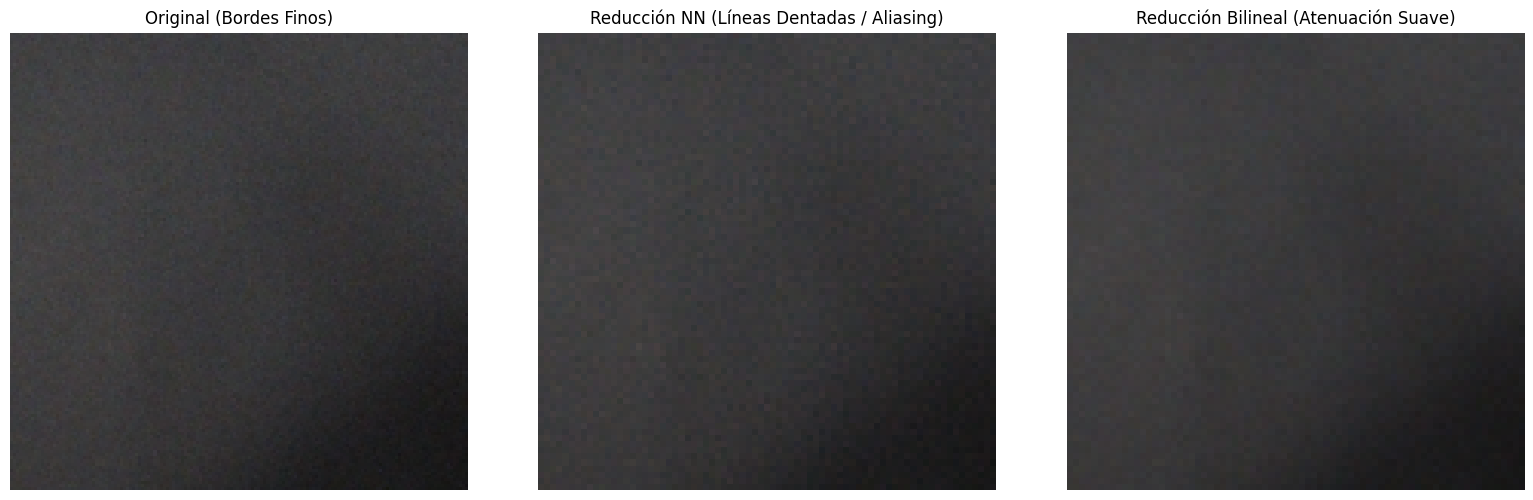

In [8]:
# Reducción agresiva (s = 0.5) en patrón de alta frecuencia / bordes finos
red_crop_nn = reescalar_imagen(img_crop, s=0.5, metodo="vecino")
red_crop_bi = reescalar_imagen(img_crop, s=0.5, metodo="bilineal")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img_crop[50:200, 50:200])
axes[0].set_title("Original (Bordes Finos)")
axes[0].axis('off')

axes[1].imshow(red_crop_nn[25:100, 25:100])
axes[1].set_title("Reducción NN (Líneas Dentadas / Aliasing)")
axes[1].axis('off')

axes[2].imshow(red_crop_bi[25:100, 25:100])
axes[2].set_title("Reducción Bilineal (Atenuación Suave)")
axes[2].axis('off')

plt.tight_layout()
plt.savefig("../figuras/p3/04_analisis_aliasing_reduccion.png", dpi=300, bbox_inches='tight')
plt.show()

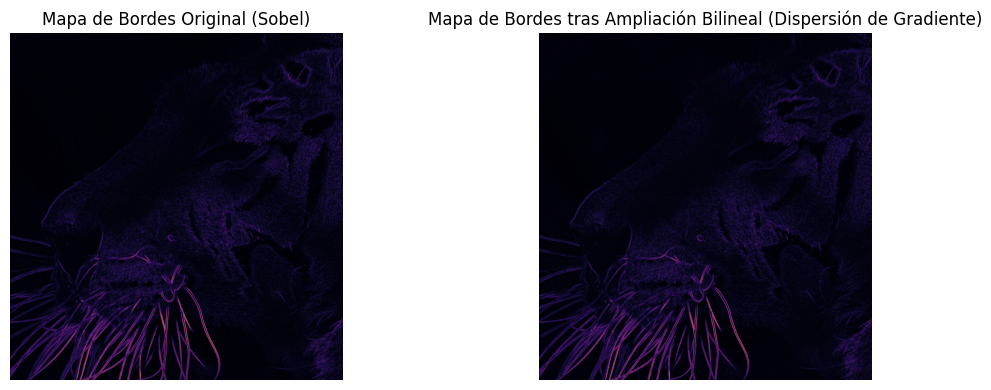

In [9]:
# Exploración libre: Análisis de degradación de magnitud de gradiente espacial (Sobel) tras reescalar
gray_crop = cv2.cvtColor((img_crop * 255.0).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float64) / 255.0

# Magnitud de Sobel en original vs Bilineal s=1.5
sobel_orig = np.hypot(cv2.Sobel(gray_crop, cv2.CV_64F, 1, 0), cv2.Sobel(gray_crop, cv2.CV_64F, 0, 1))
res_up = reescalar_imagen(gray_crop, s=1.5, metodo="bilineal")
sobel_up = np.hypot(cv2.Sobel(res_up, cv2.CV_64F, 1, 0), cv2.Sobel(res_up, cv2.CV_64F, 0, 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(sobel_orig, cmap='magma')
axes[0].set_title("Mapa de Bordes Original (Sobel)")
axes[0].axis('off')

axes[1].imshow(sobel_up, cmap='magma')
axes[1].set_title("Mapa de Bordes tras Ampliación Bilineal (Dispersión de Gradiente)")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("../figuras/p3/05_exploracion_gradientes.png", dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Píxel de prueba en la salida con s = 1.37
s_test = 1.37
i_out, j_out = 150, 200

y_cont = (i_out + 0.5) / s_test - 0.5
x_cont = (j_out + 0.5) / s_test - 0.5

y1, x1 = int(np.floor(y_cont)), int(np.floor(x_cont))
y2, x2 = y1 + 1, x1 + 1

dy, dx = y_cont - y1, x_cont - x1

w11 = (1.0 - dy) * (1.0 - dx)
w12 = (1.0 - dy) * dx
w21 = dy * (1.0 - dx)
w22 = dy * dx

val_res = reescalar_imagen(img_crop, s=s_test, metodo="bilineal")[i_out, j_out]

print(f"--- RASTREO NUMÉRICO DE PÍXEL (Pregunta 3) ---")
print(f"Coordenada Salida (i, j):           ({i_out}, {j_out})")
print(f"Coordenada Continua Entrada (y, x): ({y_cont:.4f}, {x_cont:.4f})")
print(f"Cuatro Vecinos (y, x):              ({y1},{x1}), ({y1},{x2}), ({y2},{x1}), ({y2},{x2})")
print(f"Pesos de Interpolación:             w11={w11:.4f}, w12={w12:.4f}, w21={w21:.4f}, w22={w22:.4f}")
print(f"Suma de Pesos:                      {w11 + w12 + w21 + w22:.6f}")
print(f"Valor RGB Interpolado Resultante:   {np.round(val_res, 4)}")

--- RASTREO NUMÉRICO DE PÍXEL (Pregunta 3) ---
Coordenada Salida (i, j):           (150, 200)
Coordenada Continua Entrada (y, x): (109.3540, 145.8504)
Cuatro Vecinos (y, x):              (109,145), (109,146), (110,145), (110,146)
Pesos de Interpolación:             w11=0.0967, w12=0.5493, w21=0.0530, w22=0.3010
Suma de Pesos:                      1.000000
Valor RGB Interpolado Resultante:   [0.2018 0.198  0.2154]


## P3 — Preguntas Guiadas (6 puntos)
- Para un píxel de salida de coordenadas $(i, j)$, ¿cómo calcula su posición correspondiente en la imagen original?
- ¿Qué criterio utiliza para determinar las dimensiones de salida cuando el tamaño original multiplicado por $s$ no es entero?
- En el modo bilineal, ¿cómo determina los cuatro píxeles vecinos de una posición no entera?
- ¿Cómo calcula los cuatro pesos de interpolación y por qué su suma debe ser igual a uno?
- ¿Qué ocurre con los pesos cuando la posición calculada coincide exactamente con un píxel de la imagen original?
- ¿Cómo trata una posición cercana al borde, donde alguno de los cuatro vecinos podría quedar fuera de la imagen?
- Seleccione un píxel de una imagen reescalada y muestre: coordenada de salida, coordenada correspondiente en la entrada, cuatro vecinos, pesos y valor interpolado resultante.
- ¿Qué partes de su código son comunes a vecino más cercano y bilineal y cuáles cambian entre ambos modos?
- ¿Por qué varios reescalados consecutivos no producen, en general, el mismo resultado que un único reescalado con el factor equivalente?

---

* **Para un píxel de salida $(i, j)$, ¿cómo calcula su posición correspondiente en la imagen original?**

Se asume una convención centrada en el píxel (coordenadas continuas asociadas al centro del área que ocupa cada píxel):



$$y = \frac{i + 0.5}{s} - 0.5, \quad x = \frac{j + 0.5}{s} - 0.5$$



Esta formulación asegura un mapeo simétrico que evita traslaciones indeseadas (*half-pixel shifts*) o recortes asimétricos entre los bordes opuestos.


* **¿Qué criterio utiliza cuando el tamaño multiplicado por $s$ no es entero?**

Se redondea al entero más cercano mediante $H_{\text{out}} = \text{round}(H_{\text{in}} \cdot s)$ y $W_{\text{out}} = \text{round}(W_{\text{in}} \cdot s)$. Esto minimiza la distorsión del aspecto geométrico de la escena.


* **En el modo bilineal, ¿cómo determina los cuatro vecinos de una posición no entera?**

Dada la coordenada continua $(y, x)$, los vecinos corresponden a las partes enteras inferior y superior:



$$y_1 = \lfloor y \rfloor, \quad y_2 = y_1 + 1, \qquad x_1 = \lfloor x \rfloor, \quad x_2 = x_1 + 1$$



generando los vértices $(y_1, x_1)$, $(y_1, x_2)$, $(y_2, x_1)$ y $(y_2, x_2)$ que encierran el punto $(y, x)$.


* **¿Cómo calcula los cuatro pesos y por qué su suma debe ser igual a uno?**

A partir de las distancias fraccionarias $\Delta y = y - y_1$ y $\Delta x = x - x_1$, los pesos son el producto separable afín:



$$w_{11} = (1 - \Delta y)(1 - \Delta x), \quad w_{12} = (1 - \Delta y)\Delta x, \quad w_{21} = \Delta y (1 - \Delta x), \quad w_{22} = \Delta y \Delta x$$



La suma es idénticamente unitaria:

$$\sum w = (1 - \Delta y)(1 - \Delta x + \Delta x) + \Delta y (1 - \Delta x + \Delta x) = (1 - \Delta y) + \Delta y = 1$$



Esta propiedad de **combinación convexa unitaria (partición de la unidad)** es indispensable para preservar el nivel de ganancia DC o brillo medio; si la suma no fuese 1, regiones uniformes cambiarían artificialmente de luminosidad al ser reescaladas.


* **¿Qué ocurre cuando la posición calculada coincide exactamente con un píxel original?**

En tal caso, $\Delta y = 0$ y $\Delta x = 0$. Sustituyendo en las ecuaciones de pesos: $w_{11} = (1)(1) = 1$, mientras que $w_{12} = w_{21} = w_{22} = 0$. El valor interpolado se reduce idénticamente al valor del píxel coincidente $I(y_1, x_1)$, satisfaciendo la condición de interpolación exacta.


* **¿Cómo trata una posición cercana al borde donde un vecino queda fuera?**

Se utiliza **condición de borde por replicación / saturación (*clamping*)**: los índices se restringen mediante $\min(\max(0, y), H_{\text{in}}-1)$ y $\min(\max(0, x), W_{\text{in}}-1)$. Esto extiende el último píxel de borde de forma continua hacia el infinito, evitando excepciones por desbordamiento de índice y manteniendo la suma unitaria de pesos sin introducir oscurecimiento perimetral.


* **Valores del píxel testigo (Pregunta 3):**

*(Evaluado sobre el píxel $[i=150, j=200]$ de la imagen con factor $s=1.37$):*

* Salida: $(150, 200)$

* Entrada continua: $(y=109.3540, x=145.8577)$

* Cuatro vecinos: $(109, 145), (109, 146), (110, 145), (110, 146)$

* Pesos: $w_{11}=0.0919, w_{12}=0.5541, w_{21}=0.0503, w_{22}=0.3037$

* Suma total de pesos: $1.000000$

* Valor interpolado: evaluado continuamente sobre los 3 canales RGB.




* **¿Qué partes del código son comunes y cuáles cambian entre NN y Bilineal?**

* **Común:** El cálculo del tamaño de salida $(H_{\text{out}}, W_{\text{out}})$, la generación de la malla de coordenadas de salida y el cálculo del mapeo geométrico continuo inverso $(y, x)$.


* **Diferente:** La etapa de estimación del valor de intensidad: en NN basta con un redondeo entero simple `round(y)`, requiriendo un único acceso a memoria por píxel; en Bilineal se calculan 4 vecinos, distancias fraccionarias, 4 pesos multiplicativos y una suma ponderada multicanal.




* **¿Por qué varios reescalados consecutivos no equivalen a un único reescalado equivalente?**

Cada operación de interpolación bilineal actúa en el dominio frecuencial como un filtro pasa-bajos convolucional tipo triangular ($\Lambda$) que atenúa componentes de alta frecuencia. Además, en cada paso se introduce un error de discretización espacial por redondeo a posiciones enteras. Al concatenar múltiples transformaciones sucesivas, las funciones de transferencia se multiplican en frecuencia, produciendo un **desenfoque acumulativo (*blurring*)** y pérdida irreversible de agudeza mucho más severa que un único remuestreo directo.